# DATA 266 Lab 1 — Task 2: Yelp Polarity sentiment bake-off
**Member:** Rajesh Paruchuri · **Data:** `fancyzhx/yelp_polarity` (560,000 train / 38,000 test, binary)

No pretrained embeddings or language models: every embedding table starts from random init and is learned with its classifier.

| | Model | Core idea |
|---|---|---|
| Baseline | **fastText-style bag of unigrams + hashed bigrams** | order-blind, but adjacent pairs ("not good") get their own vectors |
| Experimental A | **BiGRU + additive attention pooling** | reads the review in both directions; attention weights the verdict tokens |
| Experimental B | **2-layer Transformer encoder written from scratch, [CLS] pooling** | every token attends to every other token in one hop |

Run (repo root): `jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=-1 task2_sentiment/rajesh_paruchuri/src/part2_sentiment.ipynb`
· smoke test: prefix with `LAB_SMOKE=1`.

In [1]:
import json, math, sys, time, csv
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()) if (Path.cwd() / "sentiment_lib.py").exists() else str(Path.cwd() / "task2_sentiment/rajesh_paruchuri/src"))
import sentiment_lib as sl

P = sl.find_paths()
R = lambda p: sl.rel(p, P["repo"])
CFG = sl.load_config(P)
SMOKE = bool(CFG["smoke"])
TAG = "smoke" if SMOKE else "full"
SEED = CFG["seed"]
sl.set_seed(SEED)
device = sl.pick_device()
HW = sl.hardware_string(device)
print("smoke:", SMOKE, "| seed:", SEED, "| device:", device, "|", HW)
import sklearn, nltk
print("torch", torch.__version__, "| sklearn", sklearn.__version__, "| nltk", nltk.__version__, "| python", sys.version.split()[0])

smoke: False | seed: 266 | device: mps | MPS (Apple GPU) on Apple M4


torch 2.11.0 | sklearn 1.8.0 | nltk 3.10.3 | python 3.13.7


## 2.1 Data preprocessing
### 2.1.1 Load, then check for missing and malformed entries

In [2]:
files = sl.download_if_missing(CFG, P)
train_df = pd.read_parquet(files["train"])
test_df = pd.read_parquet(files["test"])
print("raw train", train_df.shape, "| raw test", test_df.shape)
print("label meaning: 0 = negative (1-2 stars), 1 = positive (3-4 stars)")
print("missing values:\n", pd.concat([train_df.isna().sum().rename("train"), test_df.isna().sum().rename("test")], axis=1))
print("exact duplicate texts in train:", int(train_df.text.duplicated().sum()),
      "| test texts that also appear in train (leakage):", int(test_df.text.isin(set(train_df.text)).sum()))
print("malformed-pattern counts (train):", sl.malformed_report(train_df.text.tolist()))
print("malformed-pattern counts (test): ", sl.malformed_report(test_df.text.tolist()))
pos = train_df.text.str.find('\\n')
ex = train_df.text[(pos > 0) & (pos < 120) & train_df.text.str.contains('\\u00', regex=False)].iloc[0]
print("\nexample raw entry with escapes:", repr(ex[:240]))
print("after repair():                 ", repr(sl.repair(ex)[:240]))

raw train (560000, 2) | raw test (38000, 2)
label meaning: 0 = negative (1-2 stars), 1 = positive (3-4 stars)
missing values:
        train  test
text       0     0
label      0     0


exact duplicate texts in train: 0 | test texts that also appear in train (leakage): 0


malformed-pattern counts (train): {'null_or_nonstring': 0, 'blank': 0, 'literal_backslash_n': 269718, 'escaped_quotes': 102352, 'html_entities': 26, 'literal_unicode_escapes': 12521, 'urls': 2580}


malformed-pattern counts (test):  {'null_or_nonstring': 0, 'blank': 0, 'literal_backslash_n': 18279, 'escaped_quotes': 6800, 'html_entities': 2, 'literal_unicode_escapes': 879, 'urls': 180}



example raw entry with escapes: 'BALL PARK PRETZEL-Would eat again. \\n\\nI came to rock bottom, looking for a great beer. Full of hops, that brings a refreshing sensation and satisfaction. I then opened the menu, scanned looking for those select bar items to pair with my gr'
after repair():                  'BALL PARK PRETZEL-Would eat again.   I came to rock bottom, looking for a great beer. Full of hops, that brings a refreshing sensation and satisfaction. I then opened the menu, scanned looking for those select bar items to pair with my grea'


### 2.1.2 Class balance and review-length distribution

class counts train: {0: 280000, 1: 280000} | test: {0: 19000, 1: 19000}
balance ratio (minority/majority) train: 1.000


,count,mean,std,min,5%,25%,50%,75%,95%,max
negative,280000.0,151.5,135.7,1.0,22.0,60.0,112.0,198.0,419.0,1052.0
positive,280000.0,114.5,104.8,1.0,16.0,44.0,84.0,150.0,316.0,998.0


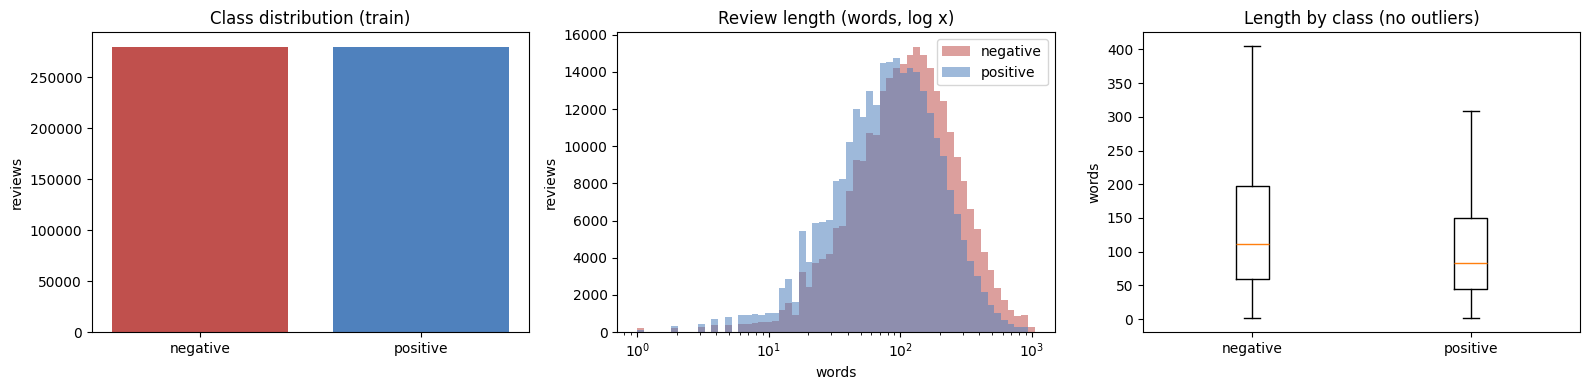

negative reviews are longer on average: 152 vs 115 words


In [3]:
for df in (train_df, test_df):
    df["n_words"] = df.text.str.split().str.len()
    df["n_chars"] = df.text.str.len()
print("class counts train:", train_df.label.value_counts().sort_index().to_dict(),
      "| test:", test_df.label.value_counts().sort_index().to_dict())
print("balance ratio (minority/majority) train: %.3f" % (train_df.label.value_counts().min() / train_df.label.value_counts().max()))
desc = train_df.groupby("label").n_words.describe(percentiles=[.05, .25, .5, .75, .95]).round(1)
desc.index = ["negative", "positive"]
display(desc)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(["negative", "positive"], train_df.label.value_counts().sort_index().values, color=["#c0504d", "#4f81bd"])
ax[0].set(title="Class distribution (train)", ylabel="reviews")
bins = np.logspace(0, np.log10(train_df.n_words.max()), 60)
for lab, name, col in [(0, "negative", "#c0504d"), (1, "positive", "#4f81bd")]:
    ax[1].hist(train_df.n_words[train_df.label == lab], bins=bins, alpha=0.55, label=name, color=col)
ax[1].set(xscale="log", title="Review length (words, log x)", xlabel="words", ylabel="reviews"); ax[1].legend()
ax[2].boxplot([train_df.n_words[train_df.label == 0], train_df.n_words[train_df.label == 1]], showfliers=False)
ax[2].set_xticks([1, 2], ["negative", "positive"])
ax[2].set(title="Length by class (no outliers)", ylabel="words")
fig.tight_layout(); fig.savefig(P["out"] / f"eda_{TAG}.png", dpi=130); plt.show()
print("negative reviews are longer on average: %.0f vs %.0f words" % tuple(train_df.groupby("label").n_words.mean()))

### 2.1.3 Split
* **Test:** the official 38,000-row test file, untouched until final evaluation.
* **Validation:** 20,000 reviews held out from the train file, stratified by label (seed 266). Used for checkpoint selection only.
* **Train:** the remaining 540,000 reviews.

In [4]:
from sklearn.model_selection import train_test_split
tr_df, va_df = train_test_split(train_df, test_size=CFG["val_size"], stratify=train_df.label, random_state=SEED)
te_df = test_df
if SMOKE:
    tr_df = tr_df.sample(CFG["n_train_smoke"], random_state=SEED)
    va_df = va_df.sample(CFG["n_val_smoke"], random_state=SEED)
    te_df = test_df.sample(CFG["n_test_smoke"], random_state=SEED)
tr_df, va_df, te_df = (d.reset_index(drop=True) for d in (tr_df, va_df, te_df))
print("train", len(tr_df), tr_df.label.value_counts().to_dict(), "| val", len(va_df), va_df.label.value_counts().to_dict(),
      "| test", len(te_df), te_df.label.value_counts().to_dict())

train 540000 {1: 270000, 0: 270000} | val 20000 {0: 10000, 1: 10000} | test 38000 {1: 19000, 0: 19000}


### 2.1.4 Text preprocessing and tokenisation
Steps in `sentiment_lib.clean_tokens`, in order:
1. **Repair** literal `\n`, escaped `\"` quotes and HTML entities (the malformed entries found above).
2. **Lowercase**, strip URLs and HTML tags.
3. **Negation-aware contractions**: `won't → will not`, `can't → can not`, `*n't → * not`.
4. **Remove punctuation, digits and special characters** (keep `a–z` only).
5. **Stopword removal** with NLTK's 179-word English list, **minus 18 sentiment-bearing words**
   (`not, no, nor, never, but, very, too, only, against, more, most, few, off, over, under, again, up, down`).
   Dropping "not" would turn "not good" into "good", which is the exact error a sentiment model must avoid.
6. **Stemming** with the Snowball (Porter2) stemmer: `amazing/amazed → amaz`. It merges inflections without needing a downloaded lexicon.
7. **Whitespace tokenisation**, then a vocabulary built from the **train split only** (min frequency 3, cap 60,000).
   Indices: 0 = `<pad>`, 1 = `<unk>`.
8. **Head+tail truncation** to 256 tokens (first 160 + last 96), because reviews often end with the verdict.

In [5]:
for t in ["I didn't love it... the food wasn't GREAT but service was amazing!!! 5/5 http://yelp.com",
          tr_df.text[3][:300]]:
    print("RAW:   ", t[:300].replace("\n", " "))
    print("TOKENS:", sl.clean_tokens(t)[:60], "\n")

cache = P["data_proc"] / f"train_arrays_{TAG}.npz"
vocab_path = P["data_proc"] / ("vocab.json" if not SMOKE else "vocab_smoke.json")
t0 = time.time()
tok_tr = sl.clean_all(tr_df.text.tolist(), CFG["n_workers"])
tok_va = sl.clean_all(va_df.text.tolist(), CFG["n_workers"])
tok_te = sl.clean_all(te_df.text.tolist(), CFG["n_workers"])
print("preprocessed %d reviews in %.0fs" % (len(tok_tr) + len(tok_va) + len(tok_te), time.time() - t0))

# entries that become empty after cleaning carry no signal: drop from train, keep (as <unk>) in val/test
empty_tr = np.array([len(t) == 0 for t in tok_tr])
print("empty after cleaning -> train:", int(empty_tr.sum()), "| val:", sum(len(t) == 0 for t in tok_va),
      "| test:", sum(len(t) == 0 for t in tok_te))
keep = ~empty_tr
tr_df = tr_df[keep].reset_index(drop=True)
tok_tr = [t for t, k in zip(tok_tr, keep) if k]

stoi, counts = sl.build_vocab(tok_tr, CFG["min_freq"], CFG["max_vocab"])
V = len(stoi)
with open(vocab_path, "w") as f:
    json.dump({"stoi": stoi, "min_freq": CFG["min_freq"], "max_vocab": CFG["max_vocab"], "built_from": "train split only"}, f)
tr_ids, tr_lens = sl.numericalize(tok_tr, stoi, CFG["max_len"], CFG["head_tokens"])
va_ids, va_lens = sl.numericalize(tok_va, stoi, CFG["max_len"], CFG["head_tokens"])
te_ids, te_lens = sl.numericalize(tok_te, stoi, CFG["max_len"], CFG["head_tokens"])
tr_y, va_y, te_y = (d.label.values.astype(np.int64) for d in (tr_df, va_df, te_df))
np.savez_compressed(cache, tr_ids=tr_ids, tr_lens=tr_lens, tr_y=tr_y, va_ids=va_ids, va_lens=va_lens, va_y=va_y,
                    te_ids=te_ids, te_lens=te_lens, te_y=te_y, vocab_size=V)

clean_len = np.array([len(t) for t in tok_tr])
oov = lambda toks: sum(w not in stoi for t in toks for w in t) / max(1, sum(len(t) for t in toks))
print("unique train tokens: %d -> vocab size %d (incl. pad/unk)" % (len(counts), V))
print("OOV rate  val %.4f | test %.4f" % (oov(tok_va), oov(tok_te)))
print("tokens/review after cleaning: mean %.1f | median %.0f | p95 %.0f | truncated (>256): %.2f%%" % (
    clean_len.mean(), np.median(clean_len), np.percentile(clean_len, 95), 100 * (clean_len > CFG["max_len"]).mean()))
print("top-25 train tokens:", [w for w, _ in counts.most_common(25)])
print("saved", R(vocab_path), "and", R(cache))
import gc
del tok_tr, tok_va, tok_te, train_df
gc.collect()

RAW:    I didn't love it... the food wasn't GREAT but service was amazing!!! 5/5 http://yelp.com
TOKENS: ['not', 'love', 'food', 'not', 'great', 'but', 'servic', 'amaz'] 

RAW:    Oh man... DON'T get me started with TAO night club. ARGH, so I came here with 5 girls total to TAO waiting for the rest of our bachelorette party.\n\n2 of the girls parted ways after only 10 mins of being there and then there was 3. The 3 of us started drinking at the bar/restaurant area first befor
TOKENS: ['oh', 'man', 'not', 'get', 'start', 'tao', 'night', 'club', 'argh', 'came', 'girl', 'total', 'tao', 'wait', 'rest', 'bachelorett', 'parti', 'girl', 'part', 'way', 'onli', 'min', 'us', 'start', 'drink', 'bar', 'restaur', 'area', 'first', 'befor'] 



preprocessed 598000 reviews in 24s
empty after cleaning -> train: 59 | val: 1 | test: 0


unique train tokens: 139713 -> vocab size 54408 (incl. pad/unk)


OOV rate  val 0.0036 | test 0.0034
tokens/review after cleaning: mean 72.4 | median 53 | p95 200 | truncated (>256): 2.33%
top-25 train tokens: ['not', 'but', 'place', 'food', 'good', 'like', 'get', 'time', 'go', 'one', 'order', 'veri', 'would', 'servic', 'up', 'great', 'back', 'no', 'realli', 'tri', 'even', 'onli', 'us', 'more', 'friend']
saved task2_sentiment/rajesh_paruchuri/data_processed/vocab.json and task2_sentiment/rajesh_paruchuri/data_processed/train_arrays_full.npz


50

### 2.1.5 Embeddings learned from scratch
None of the three models loads external vectors. Each has its own `nn.Embedding(V, d)`, randomly initialised and trained
end-to-end by back-propagating the classification loss:
* **Baseline:** 64-dim, over V unigrams plus 262,144 hashed bigram buckets. Low dimension, because the classifier on top is only linear.
* **Exp A / Exp B:** 128-dim word embeddings. Exp B also learns a 257×128 position-embedding table and a [CLS] vector.

After training (section 2.2), nearest-neighbour lookups in the learned embedding spaces show the vectors picked up sentiment.

## 2.2 Model training and evaluation
Shared setup: AdamW, linear warm-up then linear decay, gradient clipping at 1.0, binary cross-entropy on one logit,
batch 256 with length-bucketed dynamic padding. The checkpoint with the lowest validation log-loss is kept.
Each model writes its own unedited raw log.

| Model | Architecture | Key hyperparameters | Why |
|---|---|---|---|
| Baseline | Embedding(V+262,144 buckets, 64) → masked mean over unigrams+bigrams → dropout 0.2 → Linear(64,1) | lr 2e-3, 4 epochs, no weight decay | Joulin et al. 2017: a near-linear n-gram model is a strong, cheap floor. Bigrams capture short negation, which a unigram mean pool cannot |
| Exp A | Embedding(V,128) → BiGRU(128/dir) → additive attention over 256-d states → dropout 0.3 → Linear(256,1) | lr 1e-3, 3 epochs, wd 0.01 | GRU has fewer gates than LSTM (faster, less overfitting); attention pooling lets the verdict sentence dominate a long review instead of only the last state |
| Exp B | Embedding(V,128) + learned positions + [CLS] → 2× pre-norm encoder block (4 heads, FFN 256, GELU) → LN → Linear(128,1) | lr 5e-4, 5% warm-up, 3 epochs, dropout 0.1 | Self-attention links negations and contrasts to distant words in one step; written from scratch (no `nn.Transformer`) |

In [6]:
# each model trains in its own process (src/train_one.py) so MPS memory is fully released between models
import subprocess
results, histories, summaries, models = {}, {}, {}, {}
for name, mcfg in CFG["models"].items():
    print("=" * 100, "\n", name, "—", mcfg["description"])
    ckpt_path = P["ckpt"] / f"{name}_{TAG}.pt"
    hist_path = P["out"] / f"{name}_history_{TAG}.json"
    if not (ckpt_path.exists() and hist_path.exists()):
        run = subprocess.run([sys.executable, str(P["src"] / "train_one.py"), name, TAG], capture_output=True, text=True)
        print(run.stdout[-6000:])
        if run.returncode != 0:
            raise RuntimeError(run.stderr[-3000:])
    else:
        print("already trained; reusing", R(ckpt_path), "(delete it to retrain)")
        print(open(P["logs"] / f"{name}_{TAG}.log").read()[-3000:])
    with open(hist_path) as f:
        h = json.load(f)
    histories[name], summaries[name] = h["hist"], h["summary"]
    model = sl.build_model(name, mcfg, V, CFG).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device)["model"])
    models[name] = model
    print("parameters: {:,} | raw log: {} | checkpoint: {}".format(
        sl.count_params(model), R(P["logs"] / f"{name}_{TAG}.log"), R(ckpt_path)))
with open(P["out"] / f"train_histories_{TAG}.json", "w") as f:
    json.dump({"histories": histories, "summaries": summaries}, f, indent=1)

 baseline_fasttext — fastText-style bag of unigram + hashed-bigram embeddings, masked mean, linear head


baseline_fasttext: 20,259,393 parameters on MPS (Apple GPU) on Apple M4
run_start=2026-10-01 22:28:17 model=baseline_fasttext smoke=False member=rajesh_paruchuri
device=mps hardware=MPS (Apple GPU) on Apple M4 torch=2.11.0 python=3.13.7
config={"description": "fastText-style bag of unigram + hashed-bigram embeddings, masked mean, linear head", "emb_dim": 64, "dropout": 0.2, "lr": 0.002, "weight_decay": 0.0, "epochs": 4, "warmup_frac": 0.02} params=20259393 n_train=539941 n_val=20000 batch_size=256 steps=8440 warmup=168
epoch=1 step=0/8440 loss=0.6913 grad_norm=0.068 lr=0.000024 elapsed=2s
epoch=1 step=400/8440 loss=0.1448 grad_norm=0.025 lr=0.001944 elapsed=735s
epoch=1 step=800/8440 loss=0.1868 grad_norm=0.027 lr=0.001847 elapsed=749s
epoch=1 step=1200/8440 loss=0.1473 grad_norm=0.020 lr=0.001750 elapsed=763s
epoch=1 step=1600/8440 loss=0.1638 grad_norm=0.015 lr=0.001654 elapsed=776s
epoch=1 step=2000/8440 loss=0.1132 grad_norm=0.030 lr=0.001557 elapsed=790s
EPOCH 1 train_loss=0.2226 

parameters: 20,259,393 | raw log: reproducibility/raw_logs/rajesh_paruchuri/task2_sentiment/baseline_fasttext_full.log | checkpoint: task2_sentiment/rajesh_paruchuri/checkpoints/baseline_fasttext_full.pt
 exp_a_bigru_attn — 1-layer BiGRU (128/dir) over learned embeddings with additive attention pooling


exp_a_bigru_attn: 7,195,649 parameters on MPS (Apple GPU) on Apple M4
run_start=2026-10-01 22:48:19 model=exp_a_bigru_attn smoke=False member=rajesh_paruchuri
device=mps hardware=MPS (Apple GPU) on Apple M4 torch=2.11.0 python=3.13.7
config={"description": "1-layer BiGRU (128/dir) over learned embeddings with additive attention pooling", "emb_dim": 128, "hidden": 128, "attn_dim": 128, "dropout": 0.3, "lr": 0.001, "weight_decay": 0.01, "epochs": 3, "warmup_frac": 0.02} params=7195649 n_train=539941 n_val=20000 batch_size=256 steps=6330 warmup=126
epoch=1 step=0/6330 loss=0.7034 grad_norm=0.152 lr=0.000016 elapsed=3s
epoch=1 step=400/6330 loss=0.2038 grad_norm=0.233 lr=0.000956 elapsed=116s
epoch=1 step=800/6330 loss=0.2187 grad_norm=0.279 lr=0.000891 elapsed=443s
epoch=1 step=1200/6330 loss=0.1684 grad_norm=0.236 lr=0.000827 elapsed=1301s
epoch=1 step=1600/6330 loss=0.1682 grad_norm=0.217 lr=0.000762 elapsed=2542s
epoch=1 step=2000/6330 loss=0.1695 grad_norm=0.247 lr=0.000698 elapsed=37

parameters: 7,195,649 | raw log: reproducibility/raw_logs/rajesh_paruchuri/task2_sentiment/exp_a_bigru_attn_full.log | checkpoint: task2_sentiment/rajesh_paruchuri/checkpoints/exp_a_bigru_attn_full.pt
 exp_b_transformer — 2-layer pre-norm Transformer encoder written from scratch, [CLS] pooling, learned positions


exp_b_transformer: 7,262,593 parameters on MPS (Apple GPU) on Apple M4
run_start=2026-10-02 03:38:38 model=exp_b_transformer smoke=False member=rajesh_paruchuri
device=mps hardware=MPS (Apple GPU) on Apple M4 torch=2.11.0 python=3.13.7
config={"description": "2-layer pre-norm Transformer encoder written from scratch, [CLS] pooling, learned positions", "emb_dim": 128, "n_layer": 2, "n_head": 4, "ffn_dim": 256, "dropout": 0.1, "lr": 0.0005, "weight_decay": 0.01, "epochs": 3, "warmup_frac": 0.05} params=7262593 n_train=539941 n_val=20000 batch_size=256 steps=6330 warmup=316
epoch=1 step=0/6330 loss=0.6810 grad_norm=0.943 lr=0.000003 elapsed=2s
epoch=1 step=400/6330 loss=0.1987 grad_norm=2.008 lr=0.000493 elapsed=220s
epoch=1 step=800/6330 loss=0.2038 grad_norm=0.798 lr=0.000460 elapsed=298s
epoch=1 step=1200/6330 loss=0.1686 grad_norm=0.426 lr=0.000426 elapsed=369s
epoch=1 step=1600/6330 loss=0.1719 grad_norm=0.523 lr=0.000393 elapsed=1446s
epoch=1 step=2000/6330 loss=0.1464 grad_norm=0.3

parameters: 7,262,593 | raw log: reproducibility/raw_logs/rajesh_paruchuri/task2_sentiment/exp_b_transformer_full.log | checkpoint: task2_sentiment/rajesh_paruchuri/checkpoints/exp_b_transformer_full.pt


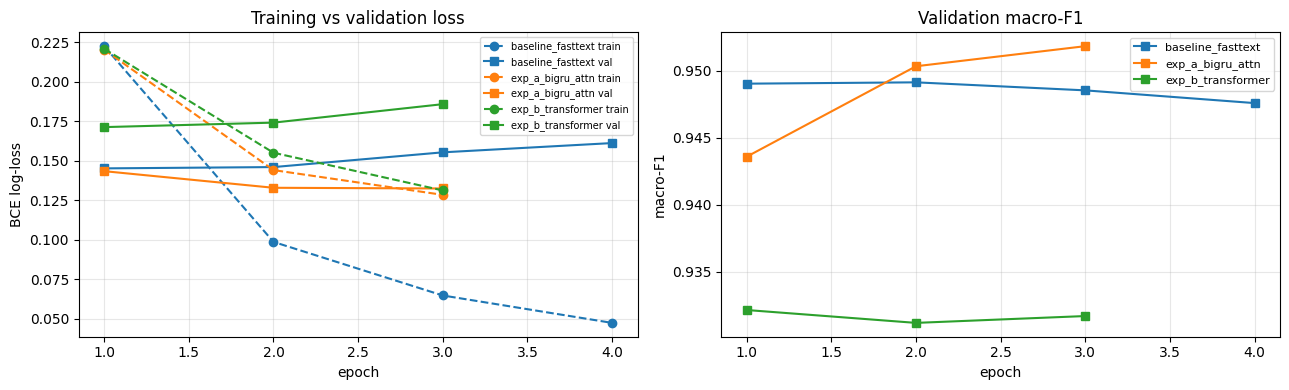

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, h in histories.items():
    l, = ax[0].plot(h["epoch"], h["train_loss"], "o--", label=f"{name} train")
    ax[0].plot(h["epoch"], h["val_loss"], "s-", color=l.get_color(), label=f"{name} val")
    ax[1].plot(h["epoch"], h["val_macro_f1"], "s-", label=name)
ax[0].set(xlabel="epoch", ylabel="BCE log-loss", title="Training vs validation loss"); ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)
ax[1].set(xlabel="epoch", ylabel="macro-F1", title="Validation macro-F1"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(P["out"] / f"training_curves_{TAG}.png", dpi=130); plt.show()

### Test-set evaluation (all required metrics)
Every metric is computed on the 38,000-review official test set at threshold 0.5.
* **ECE** uses 15 equal-width bins on the confidence of the predicted class.
* **Confidence intervals** come from a 1,000-resample percentile bootstrap.
* **McNemar** is paired on the same test reviews; I report both the exact binomial p and the continuity-corrected χ² p.

In [8]:
probs, infer_eps = {}, {}
for name, model in models.items():
    sl.sync(device); t0 = time.time()
    probs[name] = sl.predict_proba(model, te_ids, te_lens, device)
    sl.sync(device); infer_eps[name] = len(te_lens) / (time.time() - t0)
    np.savez_compressed(P["out"] / f"{name}_test_predictions_{TAG}.npz", prob_pos=probs[name], label=te_y)

all_metrics, cms = {}, {}
for name in models:
    m, cm = sl.full_metrics(te_y, probs[name], CFG["bootstrap_resamples"], SEED, CFG["ece_bins"])
    all_metrics[name], cms[name] = m, cm

base = "baseline_fasttext"
mcn = {name: sl.mcnemar(te_y, (probs[base] >= .5).astype(int), (probs[name] >= .5).astype(int))
       for name in models if name != base}

q = np.percentile(te_df.n_words, [25, 50, 75])
masks = sl.slice_masks([sl.repair(t) for t in te_df.text], te_df.n_words.values, q)
slices = {name: sl.slice_metrics(te_y, probs[name], masks) for name in models}

show = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_micro", "f1_weighted", "roc_auc", "pr_auc", "mcc", "brier", "ece"]
display(pd.DataFrame(all_metrics).T[show].round(4))
ci = pd.DataFrame({n: {k: f"[{m[k + '_ci95_low']:.4f}, {m[k + '_ci95_high']:.4f}]" for k in ("accuracy", "macro_f1", "mcc")}
                   for n, m in all_metrics.items()}).T
print("95% bootstrap CIs"); display(ci)
print("McNemar vs baseline"); display(pd.DataFrame(mcn).T)

,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,f1_weighted,roc_auc,pr_auc,mcc,brier,ece
baseline_fasttext,0.9515,0.9515,0.9515,0.9515,0.9515,0.9515,0.9874,0.9872,0.9030,0.0382,0.0145
exp_a_bigru_attn,0.9523,0.9523,0.9523,0.9523,0.9523,0.9523,0.9903,0.9906,0.9046,0.0363,0.0147
exp_b_transformer,0.9323,0.9323,0.9323,0.9323,0.9323,0.9323,0.9830,0.9837,0.8645,0.0494,0.0079


95% bootstrap CIs


,accuracy,macro_f1,mcc
baseline_fasttext,"[0.9496, 0.9535]","[0.9496, 0.9535]","[0.8992, 0.9071]"
exp_a_bigru_attn,"[0.9502, 0.9545]","[0.9502, 0.9545]","[0.9005, 0.9090]"
exp_b_transformer,"[0.9298, 0.9346]","[0.9298, 0.9346]","[0.8596, 0.8691]"


McNemar vs baseline


,b_baseline_right_model_wrong,c_baseline_wrong_model_right,chi2_cc,p_chi2,p_exact
exp_a_bigru_attn,745.0,776.0,0.591716,4.417563e-01,4.417666e-01
exp_b_transformer,1197.0,466.0,320.444979,1.158712e-71,4.333892e-74


In [9]:
sl_df = pd.concat({n: pd.DataFrame(s).T for n, s in slices.items()}, axis=1)
print("Per-slice macro-F1 / error rate (test)")
display(sl_df.round(4))
cost = pd.DataFrame({n: {"params": summaries[n]["params"], "train_time_sec": summaries[n]["train_time_sec"],
                         "train_examples_per_sec": summaries[n]["train_examples_per_sec"],
                         "test_inference_examples_per_sec": infer_eps[n],
                         "peak_device_memory_mb": summaries[n]["peak_device_memory_mb"],
                         "peak_mps_driver_memory_mb": summaries[n]["peak_mps_driver_memory_mb"],
                         "peak_process_rss_mb": summaries[n]["peak_process_rss_mb"],
                         "nan_steps": summaries[n]["nan_count"], "hardware": summaries[n]["hardware"]} for n in models}).T
display(cost)

Per-slice macro-F1 / error rate (test)


baseline_fasttext                      \
                                              n macro_f1 error_rate   
len_Q1_<=51w                             9590.0   0.9484     0.0495   
len_Q2_51-97w                            9450.0   0.9518     0.0480   
len_Q3_97-173w                           9502.0   0.9518     0.0481   
len_Q4_>173w                             9458.0   0.9491     0.0483   
has_negation                            28375.0   0.9476     0.0506   
no_negation                              9625.0   0.9412     0.0423   
has_contrast(but/however/...)           22626.0   0.9451     0.0544   
no_contrast                             15374.0   0.9593     0.0399   
negation_and_contrast                   19814.0   0.9433     0.0549   
non_english                               133.0   0.8747     0.1128   

                              exp_a_bigru_attn                      \
                                             n macro_f1 error_rate   
len_Q1_<=51w                            9590.0   0.9466     0.0512   
len_Q2_51-97w                           9450.0   0.9548     0.0450   
len_Q3_97-173w                          9502.0   0.9545     0.0455   
len_Q4_>173w                            9458.0   0.9485     0.0491   
has_negation                           28375.0   0.9495     0.0489   
no_negation                             9625.0   0.9386     0.0442   
has_contrast(but/however/...)          22626.0   0.9470     0.0525   
no_contrast                            15374.0   0.9585     0.0406   
negation_and_contrast                  19814.0   0.9454     0.0530   
non_english                              133.0   0.8099     0.1729   

                              exp_b_transformer                      
                                              n macro_f1 error_rate  
len_Q1_<=51w                             9590.0   0.9290     0.0681  
len_Q2_51-97w                            9450.0   0.9318     0.0679  
len_Q3_97-173w                           9502.0   0.9302     0.0697  
len_Q4_>173w                             9458.0   0.9311     0.0652  
has_negation                            28375.0   0.9249     0.0725  
no_negation                              9625.0   0.9248     0.0536  
has_contrast(but/however/...)           22626.0   0.9230     0.0762  
no_contrast                             15374.0   0.9435     0.0553  
negation_and_contrast                   19814.0   0.9196     0.0778  
non_english                               133.0   0.7809     0.2030

,params,train_time_sec,train_examples_per_sec,test_inference_examples_per_sec,peak_device_memory_mb,peak_mps_driver_memory_mb,peak_process_rss_mb,nan_steps,hardware
baseline_fasttext,20259393,1195.180215,1807.061373,56945.902598,309.947998,2786.578125,1873.0625,0,MPS (Apple GPU) on Apple M4
exp_a_bigru_attn,7195649,17402.580178,93.079473,7178.336984,126.75708,4031.59375,1962.625,0,MPS (Apple GPU) on Apple M4
exp_b_transformer,7262593,9084.379883,178.308594,4467.362229,129.634033,10129.65625,1295.796875,0,MPS (Apple GPU) on Apple M4


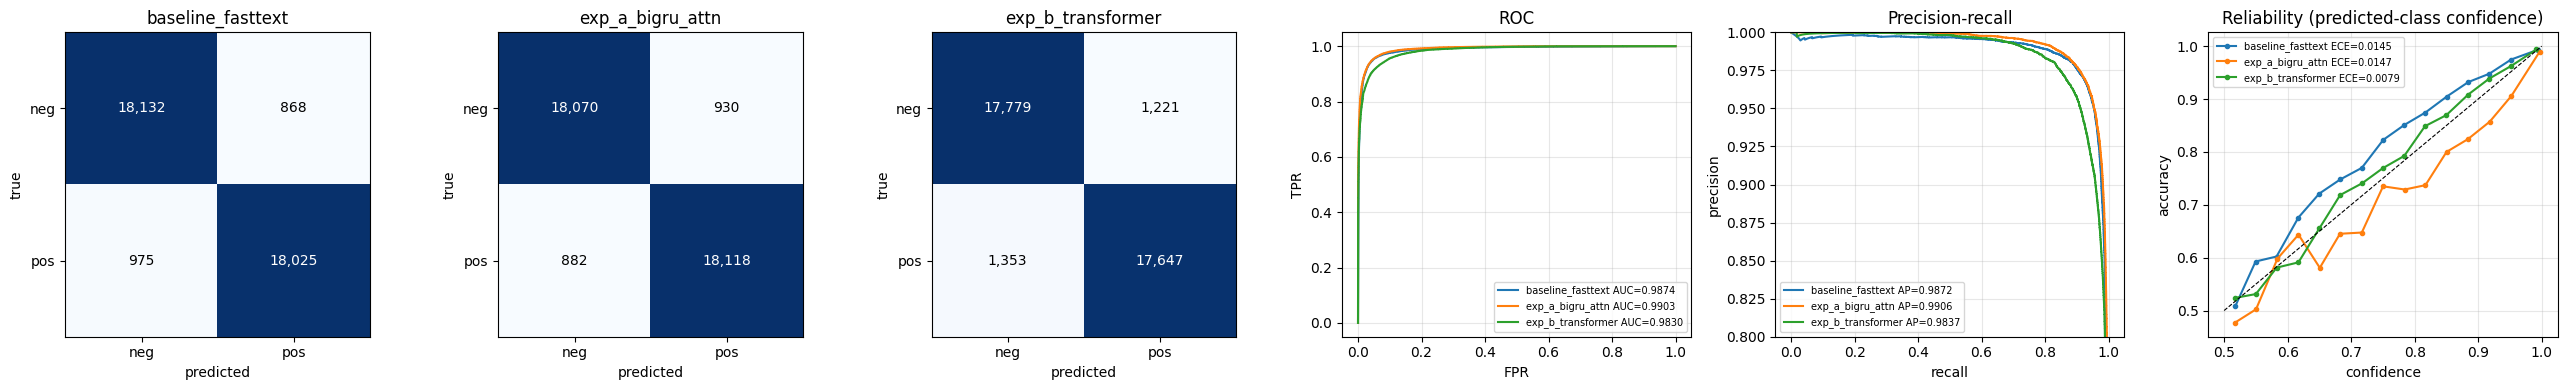

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve
fig, ax = plt.subplots(1, 3 + 3, figsize=(26, 4))
for i, name in enumerate(models):
    cm = cms[name]
    ax[i].imshow(cm, cmap="Blues")
    for (r, c), v in np.ndenumerate(cm):
        ax[i].text(c, r, f"{v:,}", ha="center", va="center", color="white" if v > cm.max() / 2 else "black")
    ax[i].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["neg", "pos"], yticklabels=["neg", "pos"],
              xlabel="predicted", ylabel="true", title=f"{name}")
for name in models:
    fpr, tpr, _ = roc_curve(te_y, probs[name]); ax[3].plot(fpr, tpr, label=f"{name} AUC={all_metrics[name]['roc_auc']:.4f}")
    pr, rc, _ = precision_recall_curve(te_y, probs[name]); ax[4].plot(rc, pr, label=f"{name} AP={all_metrics[name]['pr_auc']:.4f}")
    _, rows = sl.ece_score(te_y, probs[name], CFG["ece_bins"])
    ax[5].plot([r[0] for r in rows], [r[1] for r in rows], "o-", ms=3, label=f"{name} ECE={all_metrics[name]['ece']:.4f}")
ax[3].set(title="ROC", xlabel="FPR", ylabel="TPR"); ax[4].set(title="Precision-recall", xlabel="recall", ylabel="precision", ylim=(0.8, 1.0))
ax[5].plot([0.5, 1], [0.5, 1], "k--", lw=.8); ax[5].set(title="Reliability (predicted-class confidence)", xlabel="confidence", ylabel="accuracy")
for a in ax[3:]:
    a.legend(fontsize=7); a.grid(alpha=.3)
fig.tight_layout(); fig.savefig(P["out"] / f"confusion_roc_pr_calibration_{TAG}.png", dpi=120); plt.show()
for name in models:
    f, a = plt.subplots(figsize=(3.6, 3.2)); cm = cms[name]; a.imshow(cm, cmap="Blues")
    for (r, c), v in np.ndenumerate(cm):
        a.text(c, r, f"{v:,}", ha="center", va="center", color="white" if v > cm.max() / 2 else "black")
    a.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["neg", "pos"], yticklabels=["neg", "pos"], xlabel="predicted", ylabel="true", title=name)
    f.tight_layout(); f.savefig(P["out"] / f"{name}_confusion_matrix_{TAG}.png", dpi=130); plt.close(f)

In [11]:
# one CSV row per model with every required metric
rows = []
for name in models:
    m, s = all_metrics[name], summaries[name]
    r = {"model": name, "description": CFG["models"][name]["description"], **{k: m[k] for k in m}}
    r["mcnemar_b_vs_baseline"] = mcn.get(name, {}).get("b_baseline_right_model_wrong", "")
    r["mcnemar_c_vs_baseline"] = mcn.get(name, {}).get("c_baseline_wrong_model_right", "")
    r["mcnemar_chi2_vs_baseline"] = mcn.get(name, {}).get("chi2_cc", "")
    r["mcnemar_p_exact_vs_baseline"] = mcn.get(name, {}).get("p_exact", "")
    for sname, v in slices[name].items():
        r[f"slice_macro_f1[{sname}]"] = v["macro_f1"]
        r[f"slice_error_rate[{sname}]"] = v["error_rate"]
        r[f"slice_n[{sname}]"] = v["n"]
    r.update({"param_count": s["params"], "train_time_sec": s["train_time_sec"],
              "train_examples_per_sec": s["train_examples_per_sec"], "test_inference_examples_per_sec": infer_eps[name],
              "peak_device_memory_mb": s["peak_device_memory_mb"],
              "peak_mps_driver_memory_mb": s["peak_mps_driver_memory_mb"], "peak_process_rss_mb": s["peak_process_rss_mb"],
              "nan_steps": s["nan_count"], "epochs": CFG["models"][name]["epochs"], "best_val_loss": s["best_val_loss"],
              "hardware": s["hardware"], "checkpoint": f"task2_sentiment/rajesh_paruchuri/checkpoints/{name}_{TAG}.pt",
              "raw_log": f"reproducibility/raw_logs/rajesh_paruchuri/task2_sentiment/{name}_{TAG}.log"})
    rows.append(r)
csv_path = P["member"] / "metrics_report.csv" if not SMOKE else P["out"] / "metrics_report_smoke.csv"
pd.DataFrame(rows).to_csv(csv_path, index=False)
with open(P["out"] / f"full_metrics_{TAG}.json", "w") as f:
    json.dump({"metrics": all_metrics, "confusion_matrices": {k: v.tolist() for k, v in cms.items()}, "mcnemar": mcn,
               "slices": slices, "slice_length_quartiles_words": q.tolist(), "cost": cost.to_dict(orient="index")}, f, indent=1, default=str)
print("saved", R(csv_path))

saved task2_sentiment/rajesh_paruchuri/metrics_report.csv


### Learned-embedding sanity check
Cosine nearest neighbours in each model's trained embedding table. Words are shown as stems.

In [12]:
itos = {i: w for w, i in stoi.items()}
def neighbours(E, word, k=8):
    if word not in stoi:
        return []
    E = torch.nn.functional.normalize(E[:V].float(), dim=1)
    sims = E @ E[stoi[word]]
    return [itos[int(i)] for i in sims.topk(k + 1).indices[1:]]
for name, model in models.items():
    E = model.emb.weight.detach().cpu()
    print(name)
    for w in ["delici", "terribl", "rude", "recommend", "slow"]:
        print(f"   {w:10s} -> {neighbours(E, w)}")

baseline_fasttext
   delici     -> ['amaz', 'awesom', 'fantast', 'excel', 'perfect', 'heaven', 'divin', 'outstand']
   terribl    -> ['overpr', 'worst', 'flavorless', 'poor', 'aw', 'horribl', 'disgust', 'bland']
   rude       -> ['bland', 'worst', 'poor', 'soggi', 'horribl', 'dirti', 'disgust', 'disappoint']
   recommend  -> ['delici', 'fantast', 'amaz', 'awesom', 'excel', 'perfect', 'cozi', 'yummi']
   slow       -> ['poor', 'disappoint', 'bland', 'terribl', 'worst', 'aw', 'flavorless', 'rude']
exp_a_bigru_attn
   delici     -> ['friperi', 'hecha', 'sweeeeeet', 'sledgehamm', 'nomad', 'sourdough', 'easi', 'ralli']
   terribl    -> ['nosed', 'tae', 'arrog', 'oversold', 'alot', 'tasteless', 'loudest', 'shishinto']
   rude       -> ['flavorless', 'amiss', 'glorifi', 'beilagen', 'sliver', 'worst', 'hut', 'acadian']
   recommend  -> ['kuroi', 'horrrrribl', 'gullet', 'lax', 'hoka', 'dramamin', 'mirugai', 'timey']
   slow       -> ['obliter', 'sabaro', 'delphin', 'coasti', 'sportsbar', 'goey'

### Manual error review — selection of 20 errors
The model under review is the **experimental model with the best validation macro-F1**, chosen on validation data, not test.
The 20 errors are:
* 5 confident false positives (true negative, highest p(pos))
* 5 confident false negatives (true positive, lowest p(pos))
* 5 near-threshold errors (smallest |p − 0.5|)
* 5 slice-specific failures, drawn at random (seed 266) from the remaining errors in the slice where the model's error rate is highest

My manual annotations (error type and a testable fix) are in `../failure_analysis.md`.

In [13]:
exp_names = [n for n in models if n != base]
val_f1 = {n: histories[n]["val_macro_f1"][int(np.argmin(histories[n]["val_loss"]))] for n in exp_names}
review = max(val_f1, key=val_f1.get)
p = probs[review]; pred = (p >= .5).astype(int); err = np.where(pred != te_y)[0]
fp_idx = [i for i in err[np.argsort(-p[err])] if te_y[i] == 0][:5]
fn_idx = [i for i in err[np.argsort(p[err])] if te_y[i] == 1][:5]
used = set(fp_idx) | set(fn_idx)
nt_idx = [i for i in err[np.argsort(np.abs(p[err] - .5))] if i not in used][:5]
used |= set(nt_idx)
worst = max(slices[review], key=lambda s: slices[review][s]["error_rate"] if slices[review][s]["n"] >= 100 else -1)
pool = [i for i in err if masks[worst][i] and i not in used]
sl_idx = list(np.random.default_rng(SEED).choice(pool, size=min(5, len(pool)), replace=False))
cases = []
for group, idxs in [("confident_false_positive", fp_idx), ("confident_false_negative", fn_idx),
                    ("near_threshold", nt_idx), (f"slice:{worst}", sl_idx)]:
    for i in idxs:
        i = int(i)
        cases.append({"group": group, "test_index": i, "true": int(te_y[i]), "pred": int(pred[i]), "p_pos": float(p[i]),
                      "n_words": int(te_df.n_words[i]), "text": sl.repair(te_df.text[i]),
                      "tokens_seen_by_model": [itos[int(t)] for t in te_ids[i, :te_lens[i]]][:80],
                      "other_models_p_pos": {n: float(probs[n][i]) for n in models if n != review}})
with open(P["out"] / f"error_cases_{review}_{TAG}.json", "w") as f:
    json.dump({"model": review, "worst_slice": worst, "val_macro_f1": val_f1, "cases": cases}, f, indent=1)
print("model reviewed:", review, "| val macro-F1:", {k: round(v, 4) for k, v in val_f1.items()}, "| worst slice:", worst)
for k, c in enumerate(cases, 1):
    print(f"\n[{k:02d}] {c['group']} | true={c['true']} pred={c['pred']} p(pos)={c['p_pos']:.3f} | {c['n_words']} words | "
          f"others: {{{', '.join(f'{n}: {v:.2f}' for n, v in c['other_models_p_pos'].items())}}}")
    print("    ", c["text"][:700].replace("\n", " "))

model reviewed: exp_a_bigru_attn | val macro-F1: {'exp_a_bigru_attn': 0.9518, 'exp_b_transformer': 0.9321} | worst slice: non_english

[01] confident_false_positive | true=0 pred=1 p(pos)=1.000 | 23 words | others: {baseline_fasttext: 1.00, exp_b_transformer: 1.00}
     Wow love the place and everything is very clean and new!  Great place to come and relax worth a try!  Cheers,  Eric Van Nguyen Visited April 2012

[02] confident_false_positive | true=0 pred=1 p(pos)=1.000 | 191 words | others: {baseline_fasttext: 0.89, exp_b_transformer: 0.92}
     About average so far as steakhouses go. My rib eye was very tasty but a little over cooked. I didn't complain because the flavor was still fantastic. I thought the process were quite out of order. I've had better for sell. Over all I'd say they are more for show than content. If you want to have a great high end steak I'd recommend Ruth Chris, LG's, Flemings, or Morton's. If you want to show off how much money you have to or make it rain, Je

## 2.3 Comparative analysis
The written comparison of my three models,
strengths, weaknesses, limitations and future work are in `../results.md`.